# 12 — Query Rounds Sweep (Sweep D)

Ablates the number of QQ (query-to-query) message-passing rounds, isolated:
holds AA/AQ at the original baseline (4/4), varies qq ∈ {0, 8, 12, 16, 24, 32}
against the qq=4 baseline (Sweep A/B/C's `pw05`/agg=multi/features-off winner,
pearson_weight=0.5, EMA + protein-weighted loss). qq=32 was only trained for
attention — distance's sweep stops at qq=24 (`checkpoints/phase_d/` contains
every checkpoint this notebook uses; see Section 1). See this session's
discussion on why qq is held at the *original* baseline for Phase E rather
than chaining forward — the same logic applies here: this and Phase E are
one-at-a-time perturbations off a shared anchor, not a chain.

## What QQ Rounds Do

Stage 3 runs kNN=8 query–query message passing for `n_qq_rounds` iterations
after the atom→query transfer in Stage 2, through a single weight-tied
`MessageLayer` reused every round ([egnn.py](../../src/models/egnn.py) —
`_QueryRefine`). Each round reaches only immediate surface neighbours (a
hard kNN cutoff, not full connectivity), so multiple rounds act as a
diffusion process — hop-by-hop propagation of charge-environment
information across the surface, which is what lets the model capture
long-range surface continuity that a purely local AQ pass cannot.

## Result: clean, monotonic through qq=12 — then a plateau

Unlike every other ladder in this project (loss weight, aggregation), the
qq=0→4→8→12 ladder is a **100%-of-bins sweep at every single step, for both
architectures** — no bin anywhere favors the lower qq value, at any
true-ESP value. Net RMSE improvement is diminishing (classic shape) but the
*sign* never reverses through qq=12. See Section 3.

| qq | Attention test r / RMSE | Distance test r / RMSE |
|---|---|---|
| 0 | 0.8382 / 2.935 | 0.8432 / 2.918 |
| 4 (baseline) | 0.8898 / 2.660 | 0.8964 / 2.573 |
| 8 | 0.9032 / 2.417 | 0.9055 / 2.402 |
| 12 | 0.9072 / 2.308 | 0.9104 / 2.272 |
| 16 | 0.9073 / 2.252 | 0.9108 / 2.190 |
| 24 | 0.9078 / 2.136 | 0.9102 / 2.149 |
| 32 | 0.9067 / 2.108 | *not trained* |

*(qq=4's test numbers above reflect whatever is currently cached in
`checkpoints/phase_a/*_pw05/test_metrics.json` — this checkpoint is one of
the ones affected by the test-time reevaluation drift documented in
`.claude/EVAL_REPRODUCIBILITY_INVESTIGATION.md`, so treat this row's exact
test values as approximate. Its val metrics are unaffected — see Section 6.)*

Past qq=12, Pearson r **plateaus rather than keeps climbing** — the
16/24/32 gains are within noise, and attention's test r even *dips* slightly
at 32. RMSE keeps inching down throughout, including where r has flattened.
Section 6 (new) digs into this with validation metrics — which, unlike the
test numbers above, are frozen at training time and immune to the
reevaluation-drift issue — and Section 8 covers the resulting decision.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))
from src.utils.config import get_data_root


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid.

    analyze_model.py saves plots with a model-name prefix (e.g.
    'attention_parity_hexbin.png'), so the actual filename is built per-run
    from run['arch'] — passing a bare 'parity_hexbin.png' here is
    deliberate, the prefix is added below.
    """
    def _path(run):
        return run["plot_dir"] / f"{run['arch']}_{filename}"

    available = [r for r in runs if _path(r).exists()]
    if not available:
        print(f"No '*_{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(_path(run)))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_metric_bars(df, title):
    if df.empty:
        print("No data to plot.")
        return
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(range(len(df)), df["Pearson r"], color="steelblue", zorder=3)
    ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=8)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df["Run"].tolist(), rotation=25, ha="right", fontsize=9)
    ax.set_ylabel("Pearson r")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

## 1. Configuration

In [2]:
THESIS_ROOT = Path("/home/student/thesis")
DATA_ROOT   = Path(get_data_root())
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

QQ_VALUES = [0, 4, 8, 12, 16, 24, 32]  # 4 = baseline, lives under phase_a not phase_d

def _qq_run(model, qq):
    if qq == 4:
        phase, suffix = "phase_a", "pw05"
    else:
        phase, suffix = "phase_d", f"qq{qq}"
    return dict(
        label=f"{model} qq={qq}" + (" (baseline)" if qq == 4 else ""),
        arch=model, qq_rounds=qq, suffix=suffix, phase=phase,
        plot_dir=EVAL_ROOT/phase/f"{model}_{suffix}",
        ckpt_dir=CKPT_ROOT/phase/f"{model}_{suffix}",
    )

# distance_qq32 was never trained — build each architecture's run list from
# whichever checkpoints actually exist under checkpoints/phase_d/ (+ the
# phase_a qq=4 baseline), rather than assuming both archs share QQ_VALUES.
ATTENTION_QQ_RUNS = [r for qq in QQ_VALUES if (r := _qq_run("attention", qq))["ckpt_dir"].exists()]
DISTANCE_QQ_RUNS  = [r for qq in QQ_VALUES if (r := _qq_run("distance",  qq))["ckpt_dir"].exists()]
ALL_QQ_RUNS = ATTENTION_QQ_RUNS + DISTANCE_QQ_RUNS

print(f"{'Run':<24}  {'Plots':>6}  {'Metrics':>8}")
print("-" * 44)
for r in ALL_QQ_RUNS:
    has_plots   = r["plot_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "test_metrics.json").exists()
    print(f"{r['label']:<24}  {'yes' if has_plots else 'no':>6}  {'yes' if has_metrics else 'no':>8}")

Run                        Plots   Metrics
--------------------------------------------
attention qq=0               yes       yes
attention qq=4 (baseline)     yes       yes
attention qq=8               yes       yes
attention qq=12              yes       yes
attention qq=16              yes       yes
attention qq=24              yes       yes
attention qq=32              yes       yes
distance qq=0                yes       yes
distance qq=4 (baseline)     yes       yes
distance qq=8                yes       yes
distance qq=12               yes       yes
distance qq=16               yes       yes
distance qq=24               yes       yes


## 2. Hexbin + Sorted Predictions

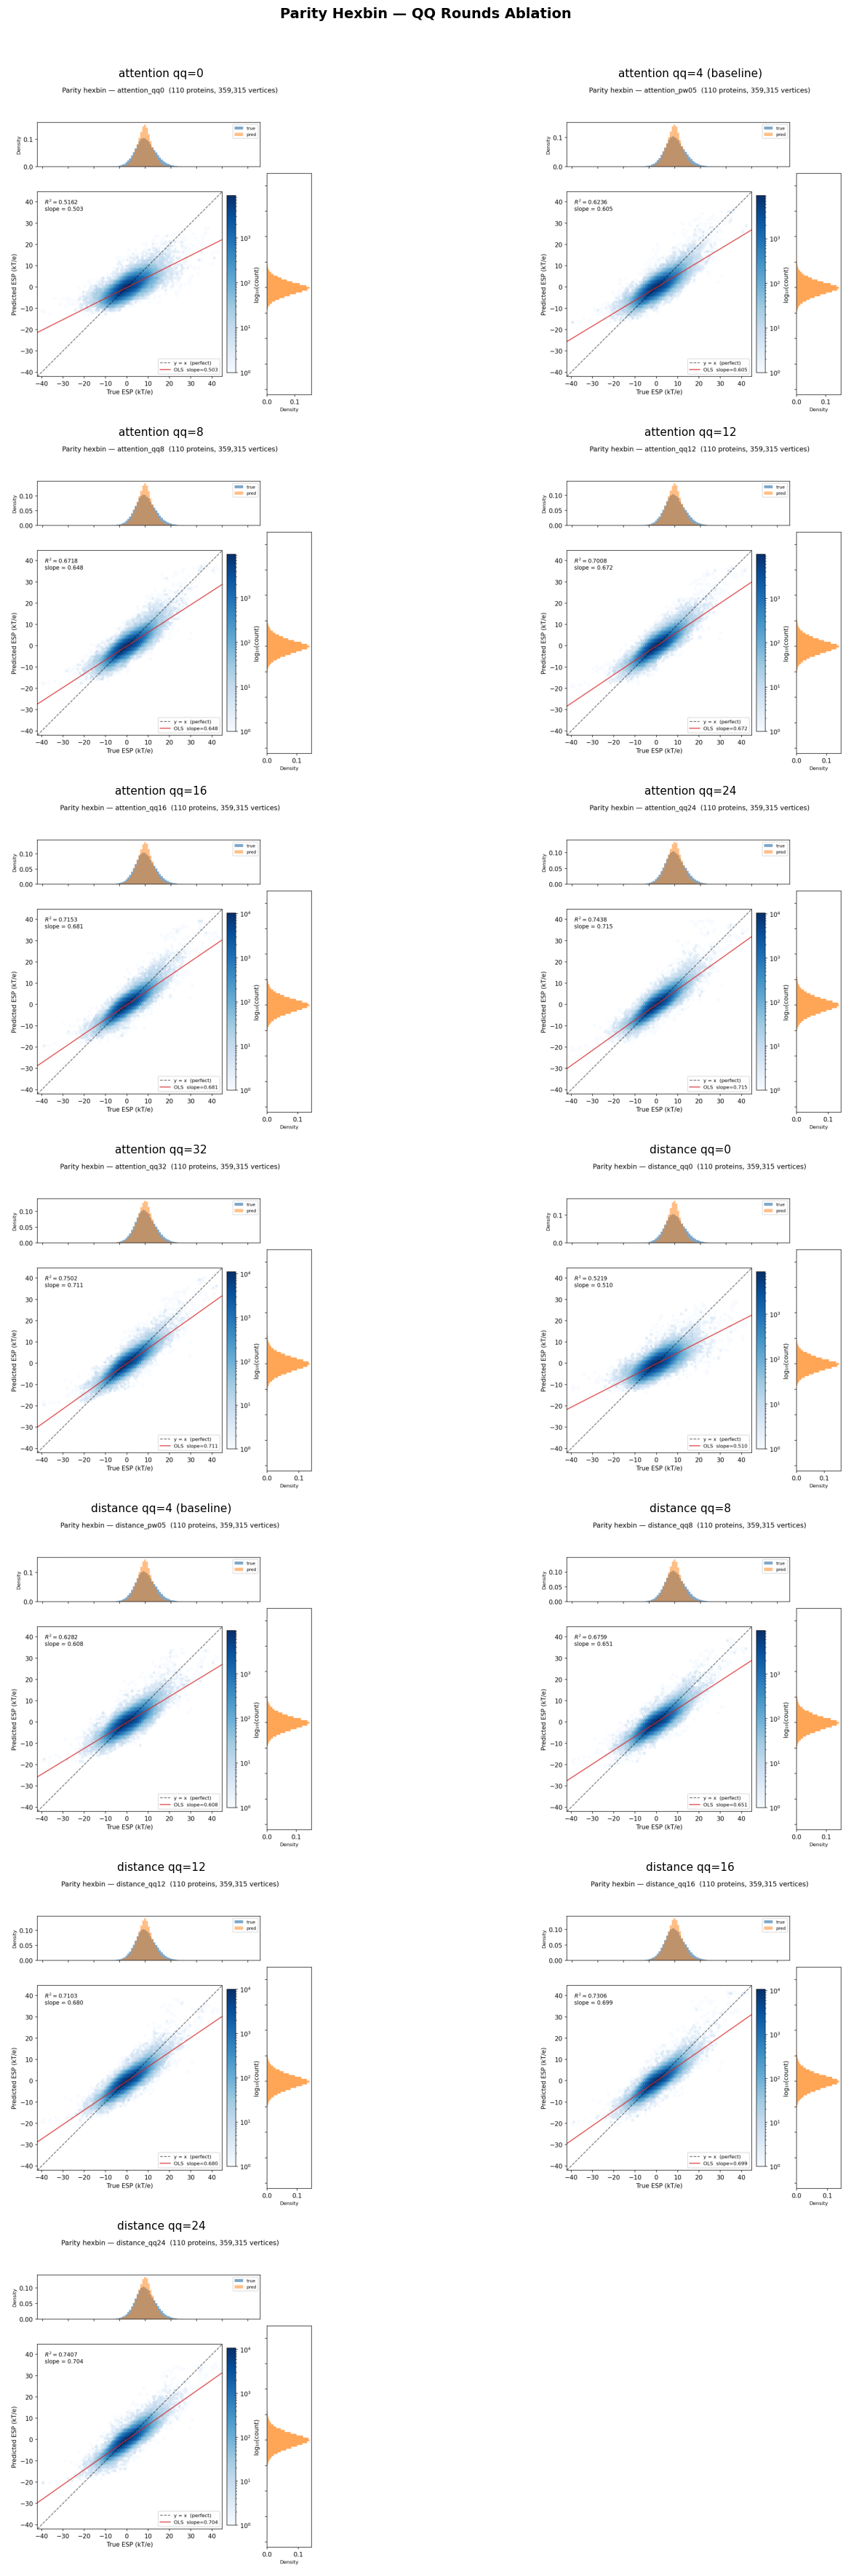

In [3]:
show_png_grid(ALL_QQ_RUNS, "parity_hexbin.png", "Parity Hexbin — QQ Rounds Ablation")

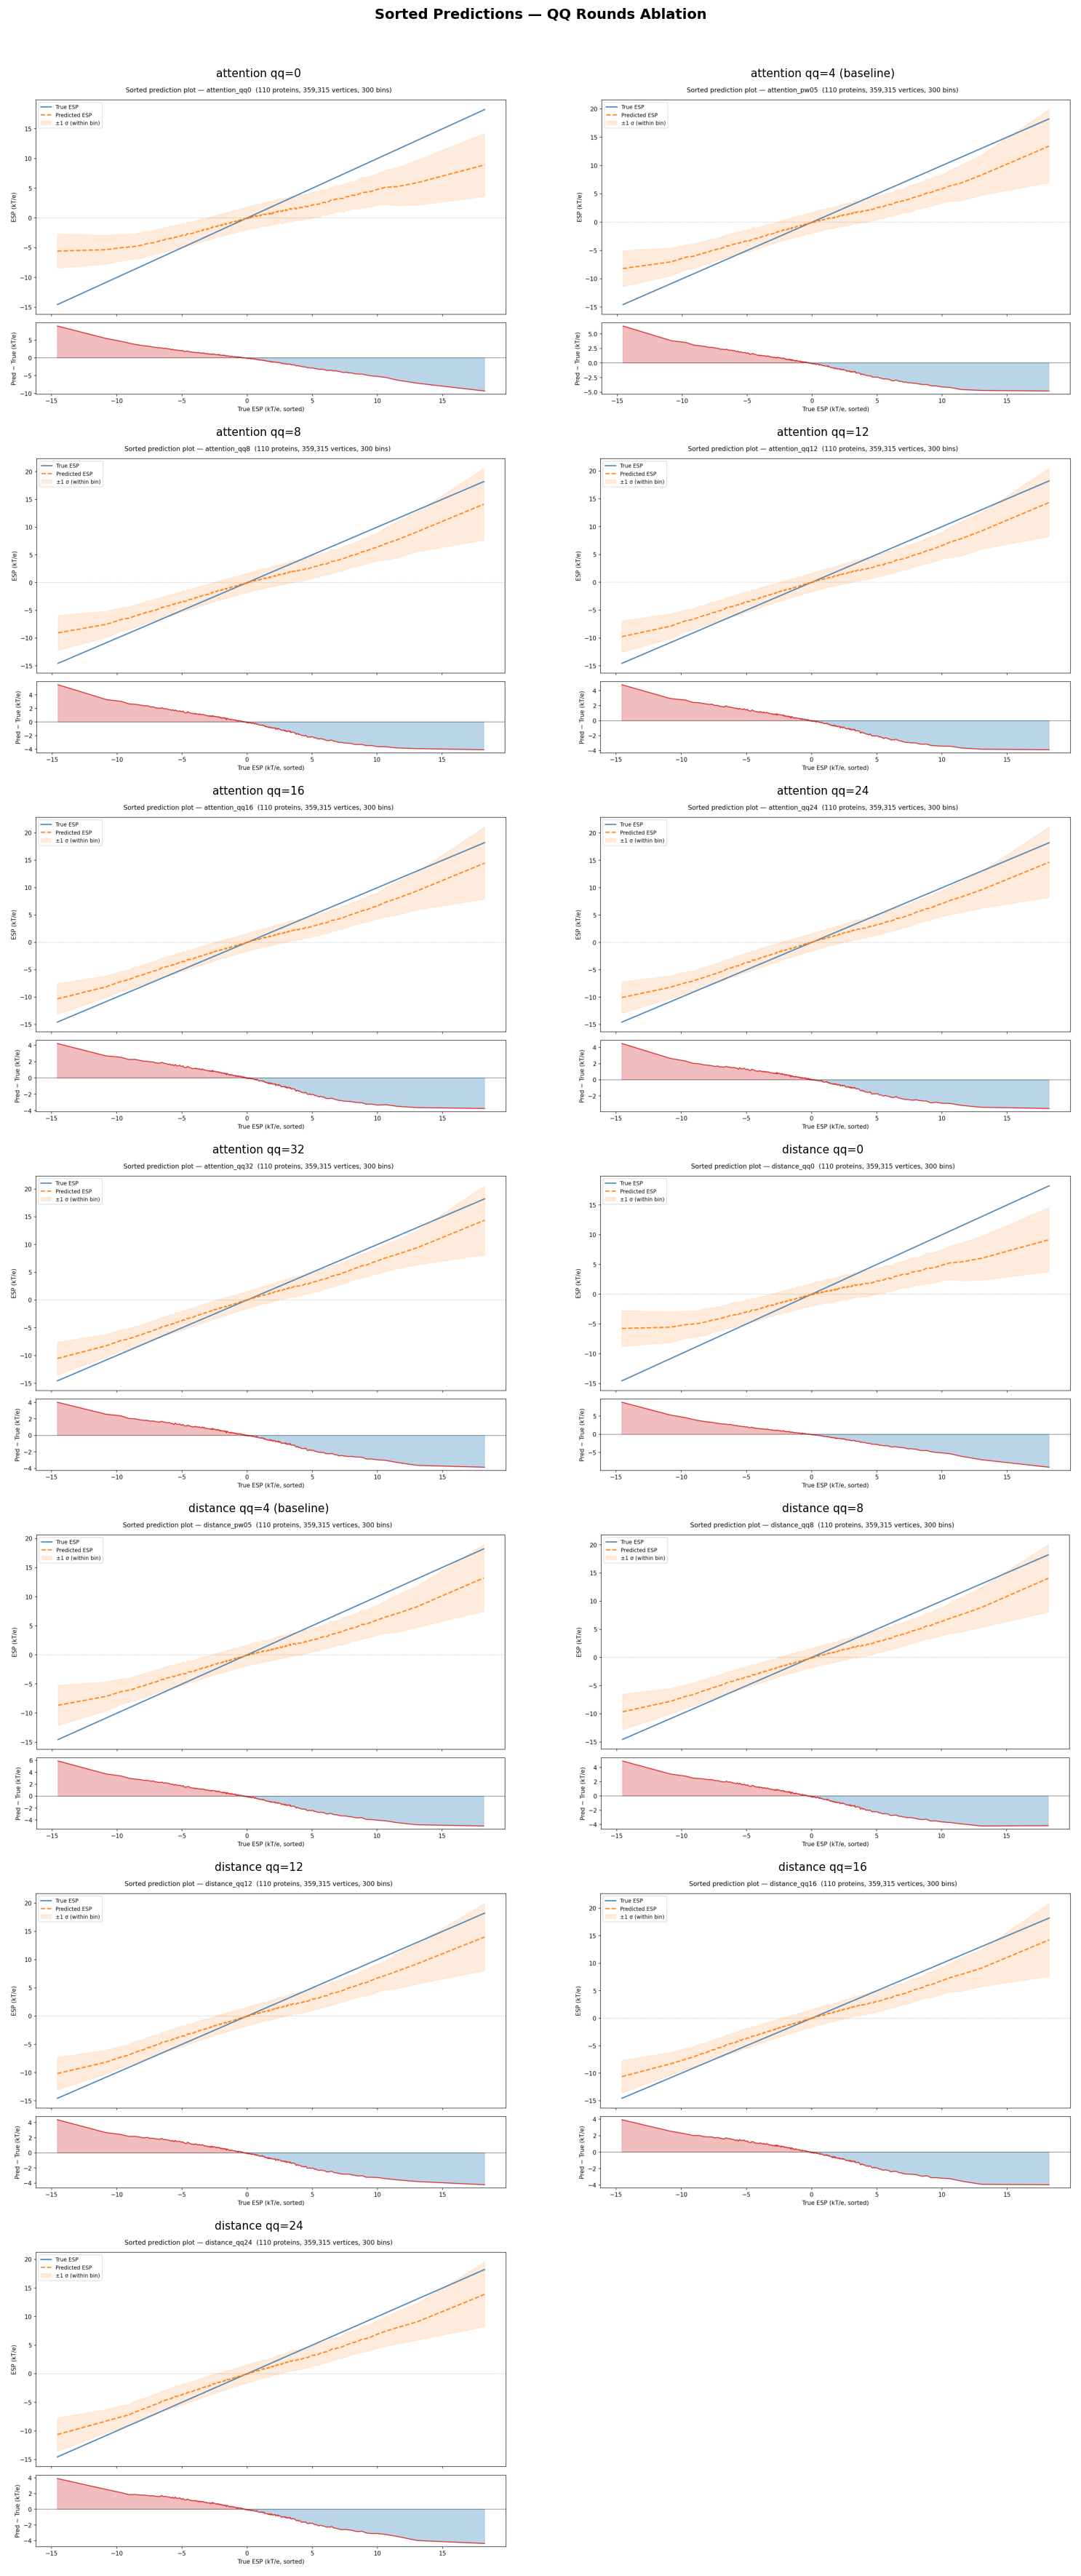

In [4]:
show_png_grid(ALL_QQ_RUNS, "sorted_predictions.png", "Sorted Predictions — QQ Rounds Ablation")

## 3. Per-Bin Comparison — Ladder and Range Breakdown

Two views: each step vs the qq=4 baseline directly, and the ladder (each
step vs the *previous* step) — see notebook 07 for why the ladder matters
more than a single net-vs-baseline number. For this axis they tell the same
story regardless: every comparison below is a 100%-bins sweep in one
direction, no exceptions.

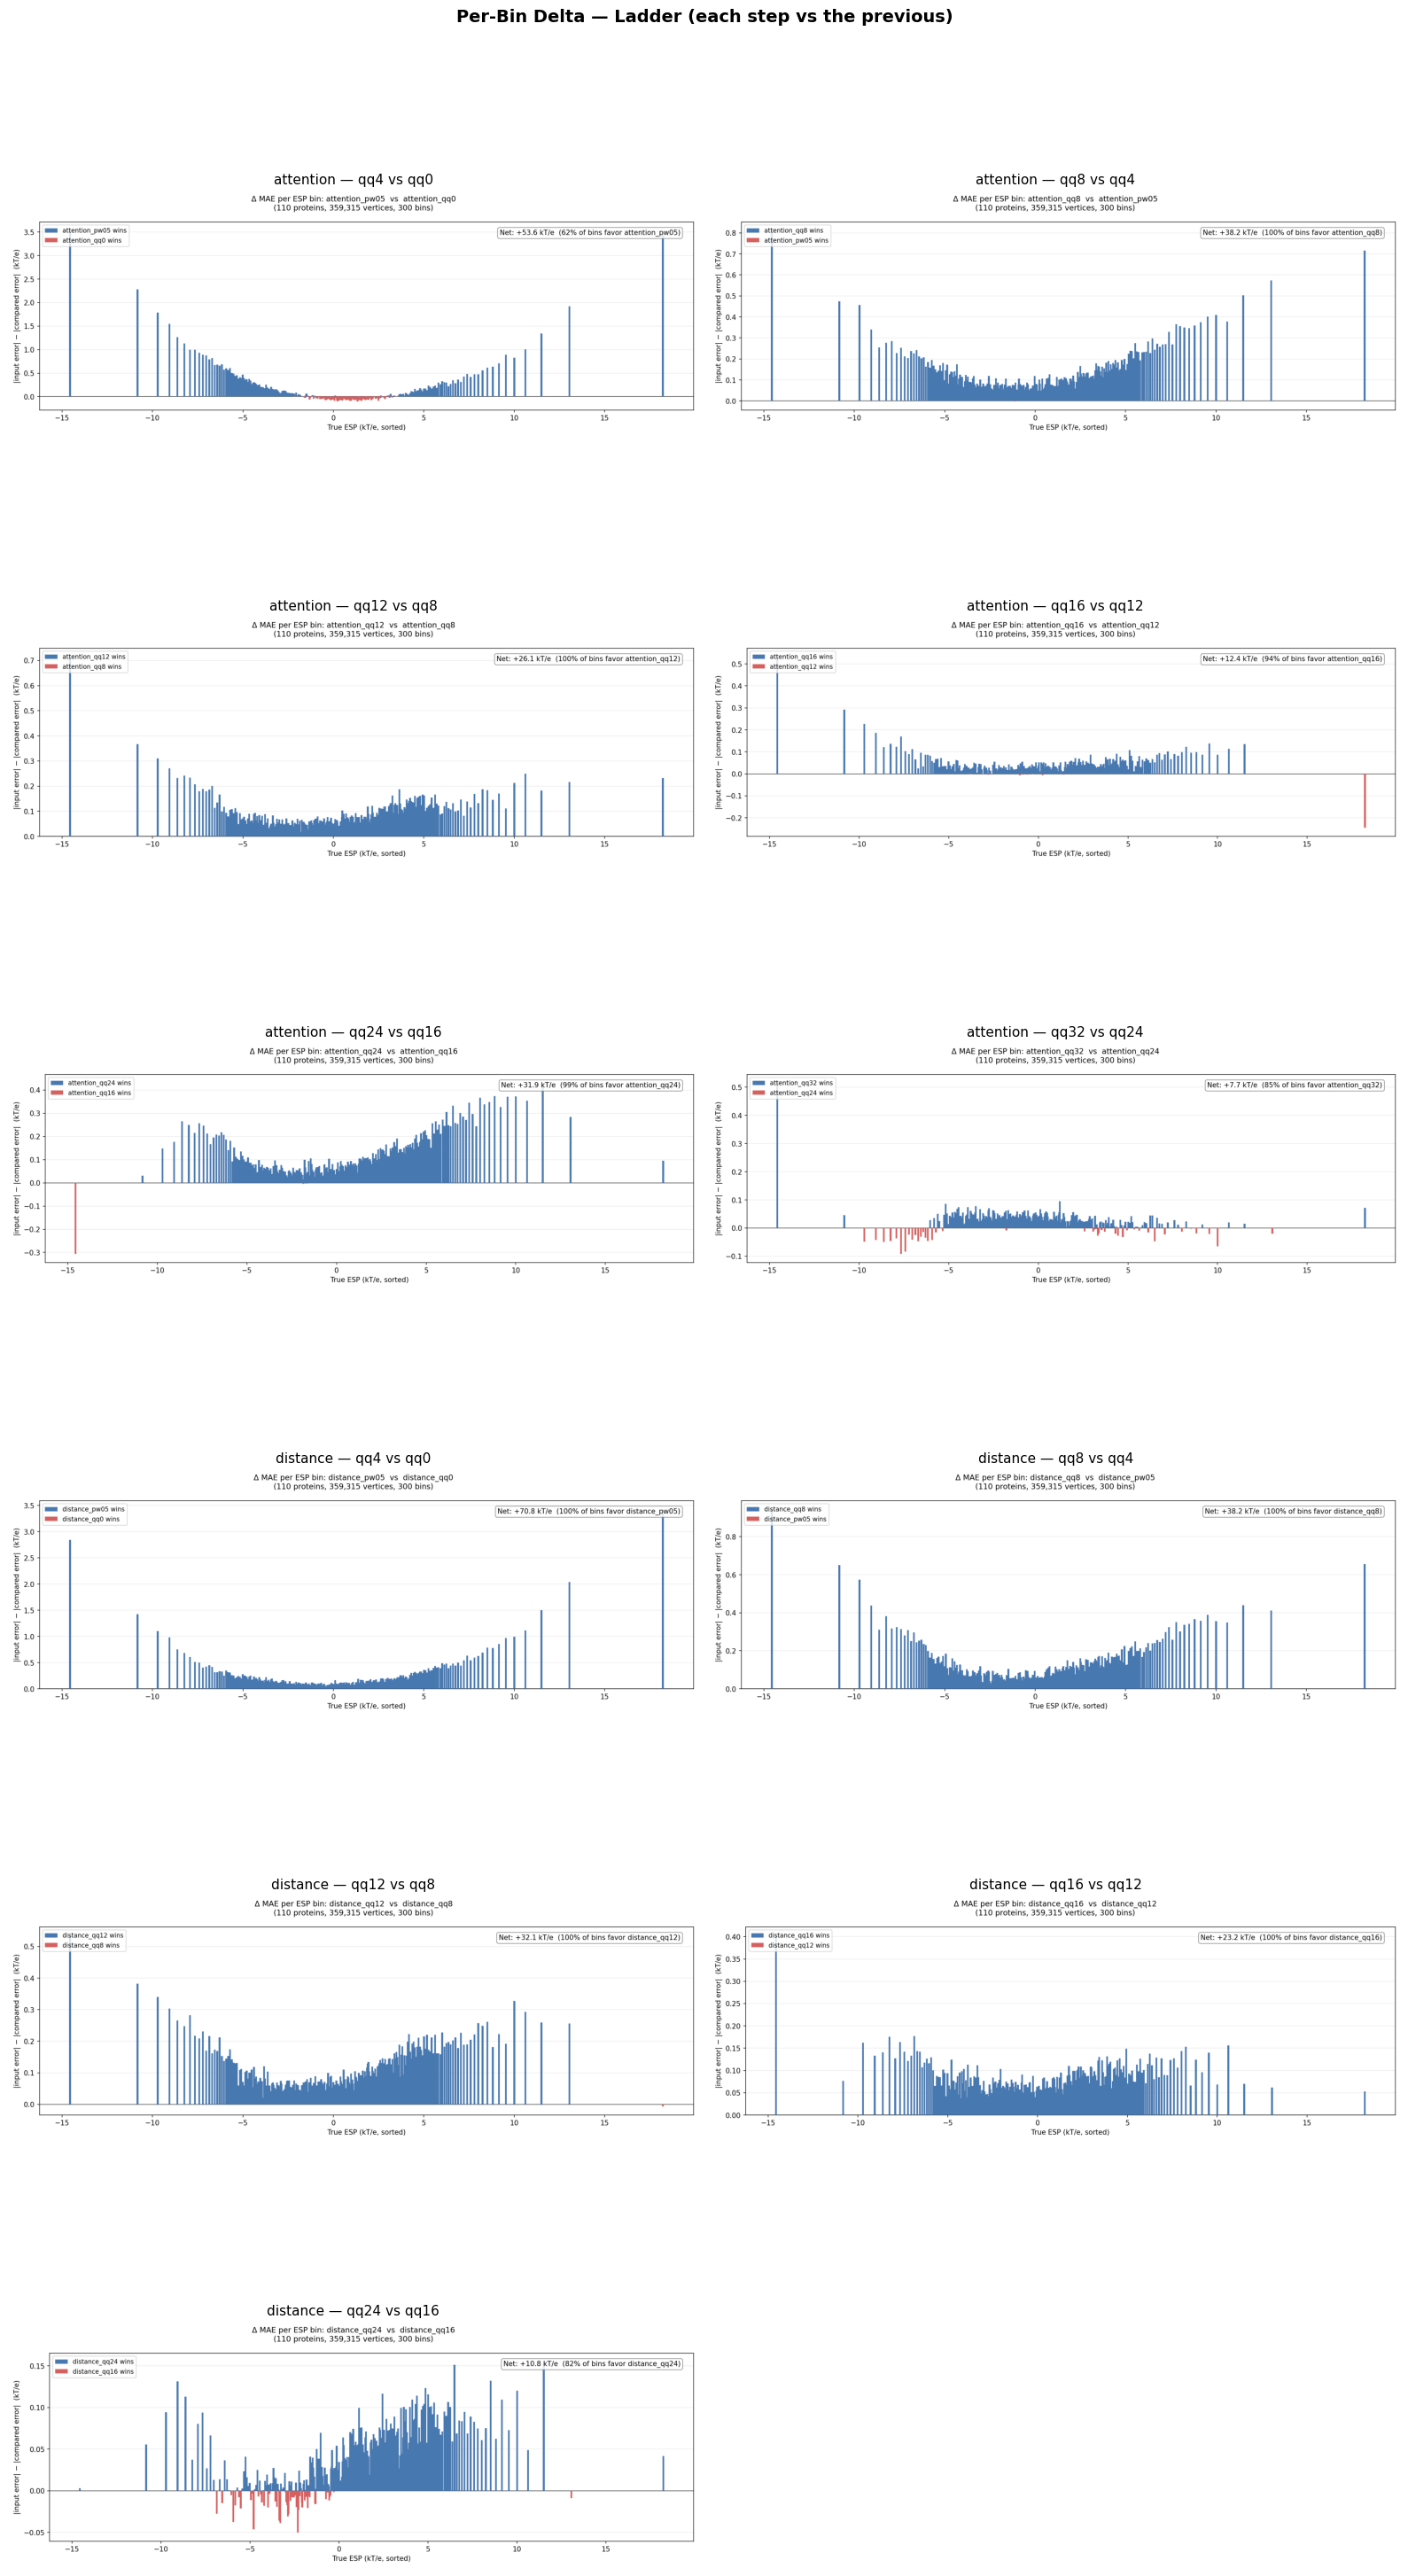


Range breakdown — ladder (each step vs the previous step):


,Comparison,range,n_bins,net_delta_kT_e,mean_delta_kT_e,pct_bins_favor_compared
0,attention qq4 vs qq0,"[-15, -8)",6,11.562,1.927,100.000
1,attention qq4 vs qq0,"[-8, -2)",86,24.923,0.290,98.837
2,attention qq4 vs qq0,"[-2, 2)",118,-3.683,-0.031,22.034
3,attention qq4 vs qq0,"[2, 8)",79,8.289,0.105,72.152
4,attention qq4 vs qq0,"[8, 15)",10,8.987,0.899,100.000
5,attention qq8 vs qq4,"[-15, -8)",6,-1.408,-0.235,0.000
6,attention qq8 vs qq4,"[-8, -2)",86,1.978,0.023,72.093
7,attention qq8 vs qq4,"[-2, 2)",118,22.088,0.187,100.000
8,attention qq8 vs qq4,"[2, 8)",79,26.978,0.341,100.000
9,attention qq8 vs qq4,"[8, 15)",10,6.031,0.603,100.000


In [5]:
from src.analysis.model_plots import range_delta_breakdown

LADDER = list(zip(QQ_VALUES[:-1], QQ_VALUES[1:]))  # [(0,4), (4,8), (8,12)]


def _ckpt(model, qq):
    phase, suffix = ("phase_a", "pw05") if qq == 4 else ("phase_d", f"qq{qq}")
    return CKPT_ROOT / phase / f"{model}_{suffix}"


def show_image_grid(items, title, ncols=2):
    available = [it for it in items if it["path"].exists()]
    if not available:
        print(f"No images found for '{title}'.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, it in zip(axes, available):
        ax.imshow(mpimg.imread(it["path"]))
        ax.set_title(it["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


# --- ladder: each step vs the previous step ---
ladder_items = [
    dict(label=f"{model} — qq{curr} vs qq{prev}",
         path=EVAL_ROOT/("phase_a" if curr==4 else "phase_d")/f"{model}_{('pw05' if curr==4 else f'qq{curr}')}"
              /f"{model}_delta_vs_{model}_{('pw05' if prev==4 else f'qq{prev}')}.png")
    for model in ["attention", "distance"]
    for prev, curr in LADDER
]
show_image_grid(ladder_items, "Per-Bin Delta — Ladder (each step vs the previous)")

print("\nRange breakdown — ladder (each step vs the previous step):")
frames = []
for model in ["attention", "distance"]:
    for prev, curr in LADDER:
        ckpt_a, ckpt_b = _ckpt(model, prev), _ckpt(model, curr)
        if not (ckpt_a/"test_predictions").exists() or not (ckpt_b/"test_predictions").exists():
            continue
        df = range_delta_breakdown(ckpt_a, ckpt_b)
        if df is None:
            continue
        df.insert(0, "Comparison", f"{model} qq{curr} vs qq{prev}")
        frames.append(df)

if frames:
    pd.set_option("display.float_format", "{:.3f}".format)
    display(pd.concat(frames, ignore_index=True))
else:
    print("No predictions cached yet.")

## 4. Training Curves

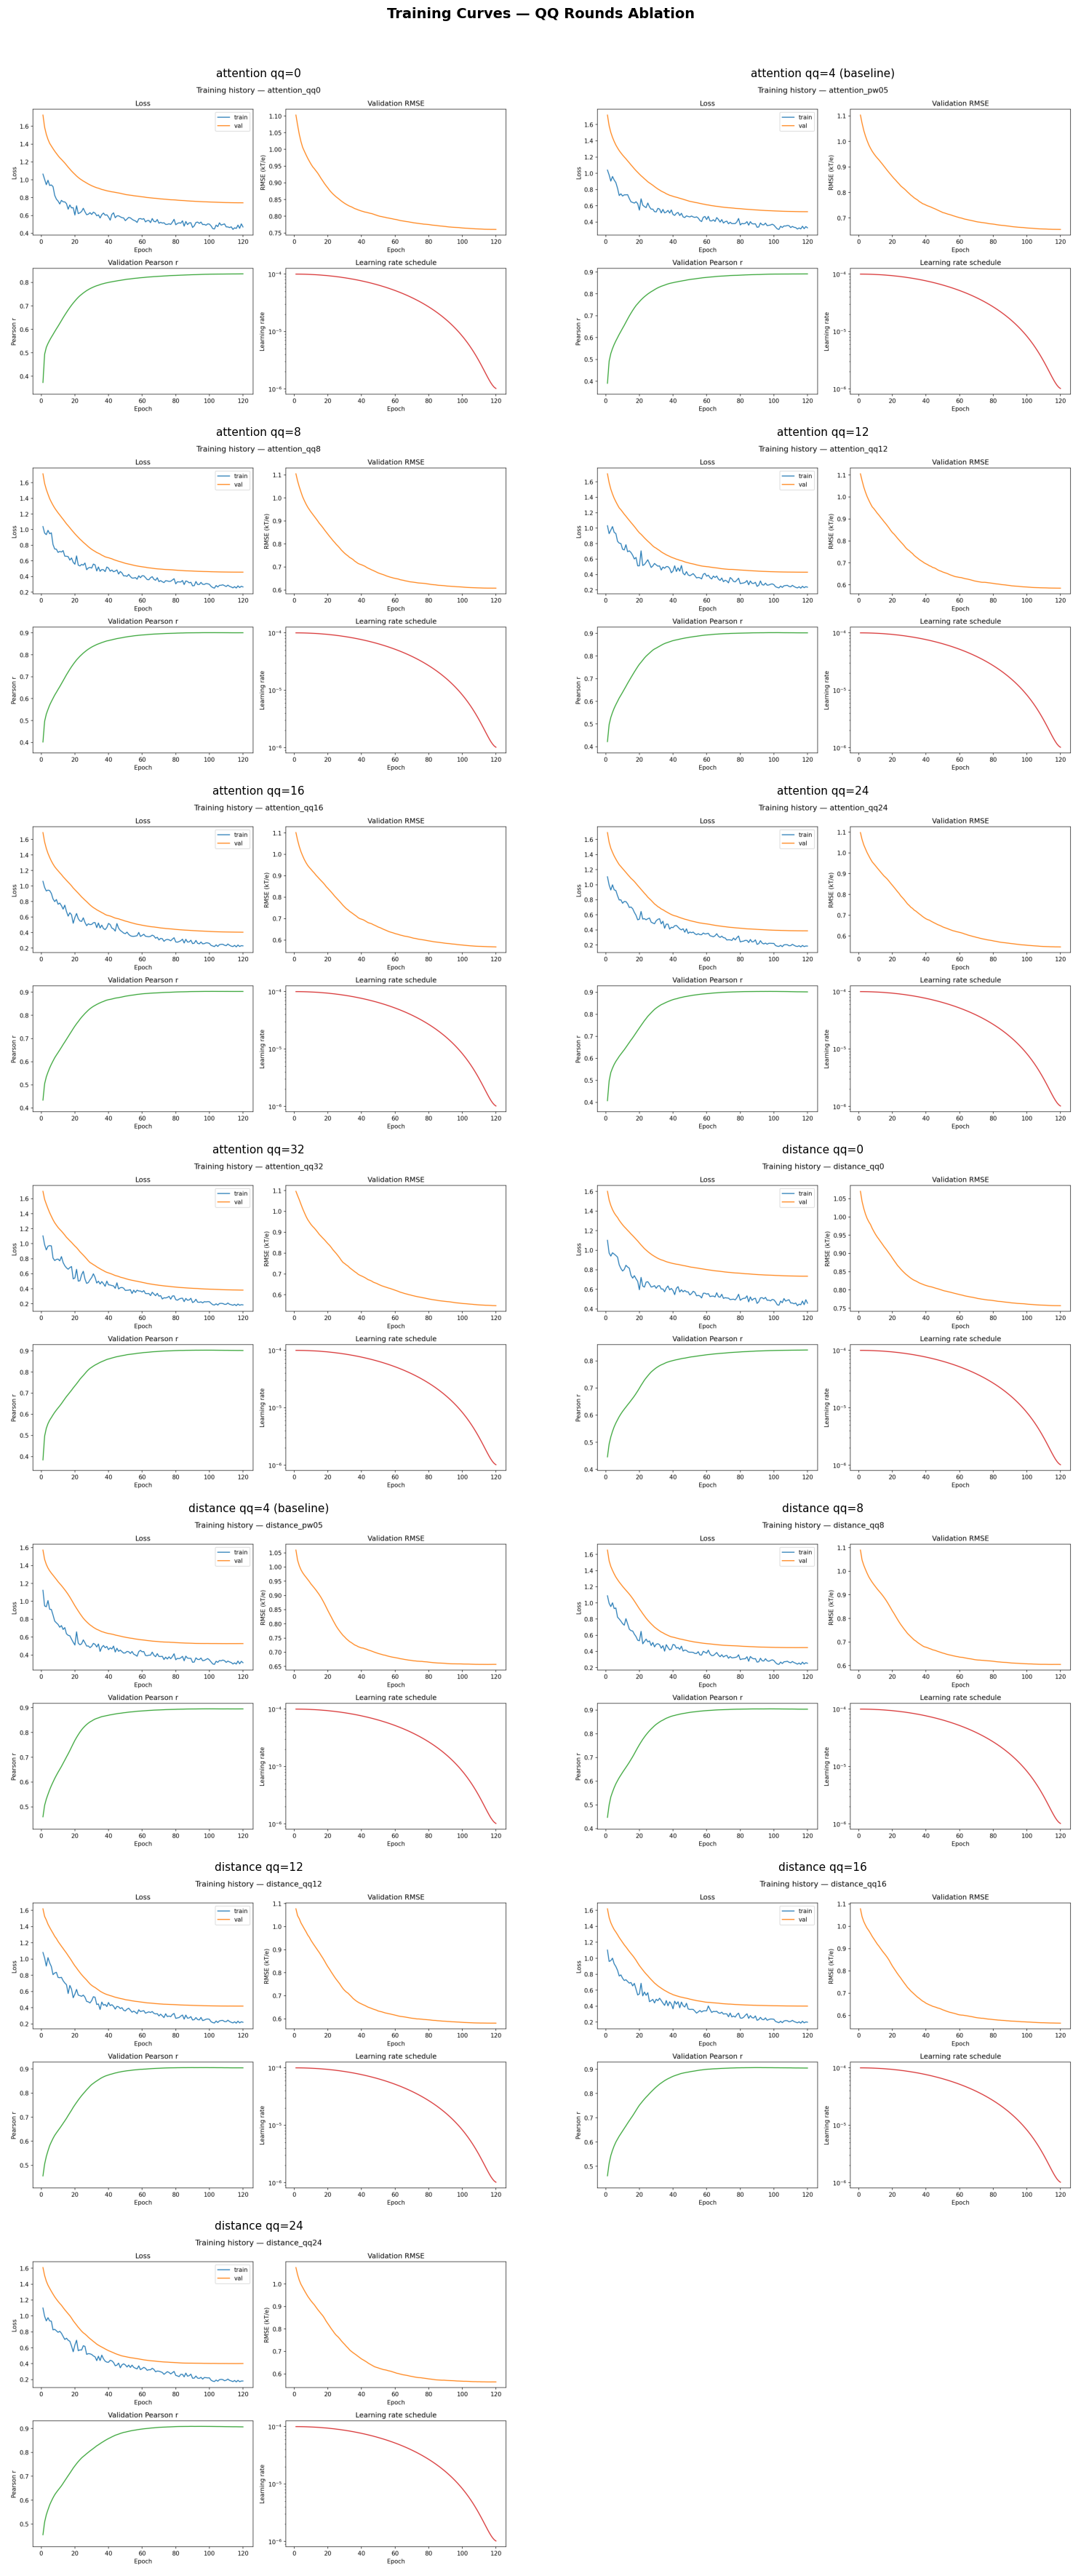

In [6]:
show_png_grid(ALL_QQ_RUNS, "training_curves.png", "Training Curves — QQ Rounds Ablation", ncols=2)

## 5. Test Metrics

,Arch,Run,QQ rounds,Suffix,Pearson r,RMSE,MAE,Val loss,Train time (s),N proteins
0,attention,attention qq=0,0,qq0,0.8382,2.9351,2.2344,0.5148,4824.6000,110
1,attention,attention qq=4 (baseline),4,pw05,0.8898,2.6598,2.0558,0.3872,NaN,110
2,attention,attention qq=8,8,qq8,0.9032,2.4173,1.8674,0.3128,5989.4000,110
3,attention,attention qq=12,12,qq12,0.9072,2.3079,1.7803,0.2824,6707.1000,110
4,attention,attention qq=16,16,qq16,0.9073,2.2515,1.7388,0.2727,6853.7000,110
5,attention,attention qq=24,24,qq24,0.9078,2.1356,1.6324,0.2482,7924.9000,110
6,attention,attention qq=32,32,qq32,0.9067,2.1080,1.6068,0.2427,8784.0000,110
7,distance,distance qq=0,0,qq0,0.8432,2.9177,2.2215,0.5062,6797.4000,110
8,distance,distance qq=4 (baseline),4,pw05,0.8964,2.5730,1.9857,0.3613,7082.3000,110
9,distance,distance qq=8,8,qq8,0.9055,2.4022,1.8584,0.3079,7615.9000,110


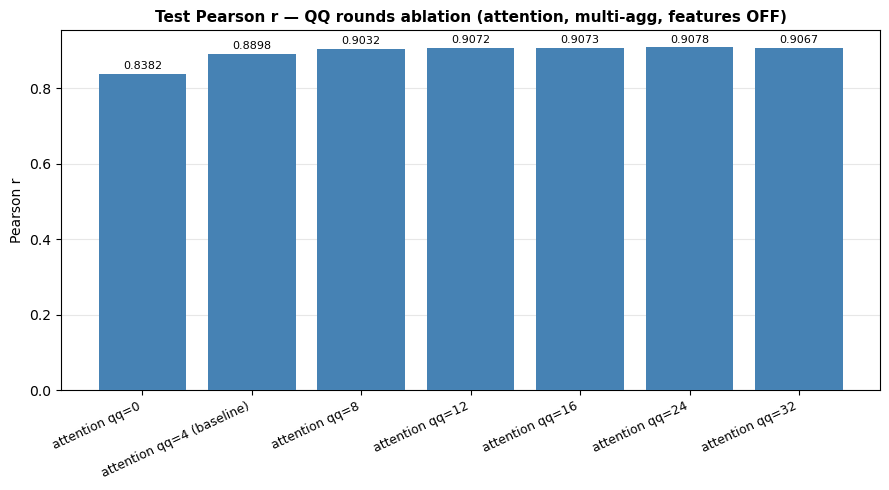

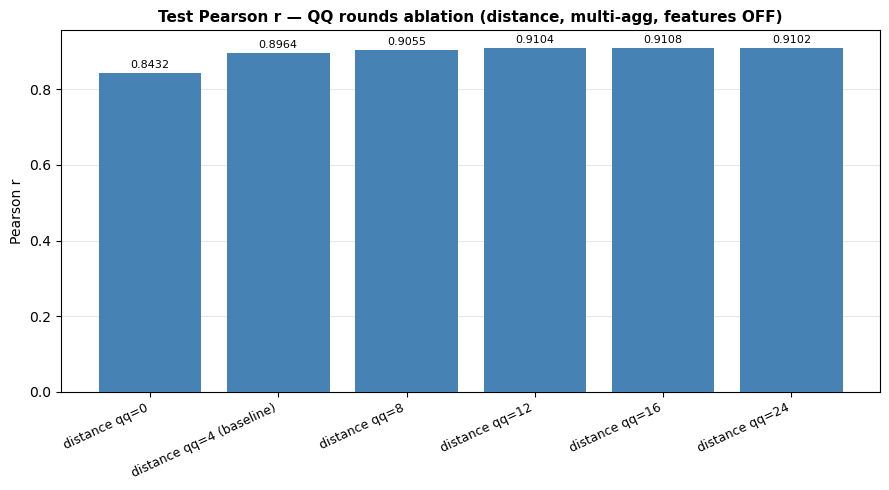

In [7]:
rows_qq = []
for run in ALL_QQ_RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        print(f"  {run['label']}: test_metrics.json not found.")
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_qq.append({
        "Arch":           run["arch"],
        "Run":            run["label"],
        "QQ rounds":      run["qq_rounds"],
        "Suffix":         run["suffix"],
        "Pearson r":      g.get("pearson_r"),
        "RMSE":           g.get("rmse"),
        "MAE":            g.get("mae"),
        "Val loss":       g.get("loss"),
        "Train time (s)": g.get("train_wall_time_s"),
        "N proteins":     g.get("n_proteins"),
    })

df_qq = pd.DataFrame(rows_qq)
pd.set_option("display.float_format", "{:.4f}".format)
display(df_qq)

for arch in ("attention", "distance"):
    df_arch = df_qq[df_qq["Arch"] == arch].copy()
    plot_metric_bars(df_arch, f"Test Pearson r — QQ rounds ablation ({arch}, multi-agg, features OFF)")

### Full-mesh metrics

In [8]:
rows_qq_fm = []
for run in ALL_QQ_RUNS:
    fm_path = run["ckpt_dir"] / "test_metrics_fullmesh.json"
    if not fm_path.exists():
        continue
    with open(fm_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_qq_fm.append({
        "Arch":       run["arch"],
        "Run":        run["label"],
        "QQ rounds":  run["qq_rounds"],
        "Suffix":     run["suffix"],
        "Pearson r":  g.get("pearson_r"),
        "RMSE":       g.get("rmse"),
        "MAE":        g.get("mae"),
        "N proteins": g.get("n_proteins"),
    })

if rows_qq_fm:
    df_qq_fm = pd.DataFrame(rows_qq_fm)
    display(df_qq_fm)
    for arch in ("attention", "distance"):
        df_arch = df_qq_fm[df_qq_fm["Arch"] == arch].copy()
        plot_metric_bars(df_arch, f"Full-mesh test Pearson r — QQ rounds ablation ({arch})")
else:
    print("No full-mesh metrics found yet.")

No full-mesh metrics found yet.


## 6. Performance Trend Across QQ Rounds — Does It Keep Helping Past 12?

Section header table already showed the shape; this plots it directly and
adds **validation** Pearson r alongside test — val is the actual selection
basis for this project (`07_train.py` saves `best_model.pt` at the epoch
with minimum val loss) and, unlike the test numbers, is frozen at training
time in `metrics.csv`, so it's unaffected by the test-time reevaluation
drift that hits `phase_a/*_pw05`
(`.claude/EVAL_REPRODUCIBILITY_INVESTIGATION.md`).

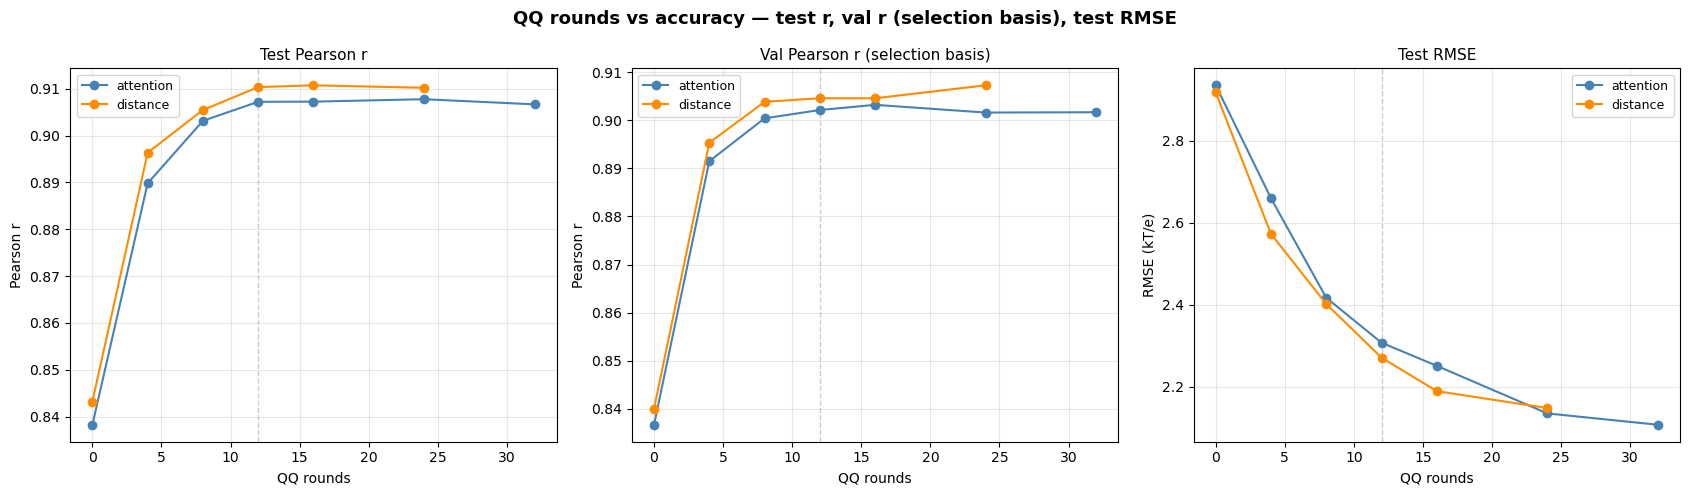

Marginal Δ val Pearson r per step (negative = this step made val r worse):
  attention:
    qq  0 → 4 :  Δval_r = +0.0548   (+0.01369 per round)
    qq  4 → 8 :  Δval_r = +0.0089   (+0.00223 per round)
    qq  8 → 12:  Δval_r = +0.0017   (+0.00043 per round)
    qq 12 → 16:  Δval_r = +0.0011   (+0.00027 per round)
    qq 16 → 24:  Δval_r = -0.0016   (-0.00020 per round)
    qq 24 → 32:  Δval_r = +0.0001   (+0.00001 per round)
  distance:
    qq  0 → 4 :  Δval_r = +0.0553   (+0.01382 per round)
    qq  4 → 8 :  Δval_r = +0.0085   (+0.00213 per round)
    qq  8 → 12:  Δval_r = +0.0007   (+0.00018 per round)
    qq 12 → 16:  Δval_r = -0.0000   (-0.00000 per round)
    qq 16 → 24:  Δval_r = +0.0027   (+0.00034 per round)


In [9]:
# Validation Pearson r / RMSE per run — the epoch that produced best_model.pt.
rows_val = []
for run in ALL_QQ_RUNS:
    csv_path = run["ckpt_dir"] / "metrics.csv"
    if not csv_path.exists():
        continue
    hist = pd.read_csv(csv_path)
    if hist.empty:
        continue
    best = hist.loc[hist["val_loss"].idxmin()]
    rows_val.append({
        "Arch":        run["arch"],
        "QQ rounds":   run["qq_rounds"],
        "Val Pearson r": best["val_pearson_r"],
        "Val RMSE":      best["val_rmse"],
    })
df_val = pd.DataFrame(rows_val).sort_values(["Arch", "QQ rounds"])

ARCH_COLORS = {"attention": "steelblue", "distance": "darkorange"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("QQ rounds vs accuracy — test r, val r (selection basis), test RMSE",
             fontsize=13, fontweight="bold")

for arch, color in ARCH_COLORS.items():
    sub_test = df_qq[df_qq["Arch"] == arch].sort_values("QQ rounds")
    sub_val  = df_val[df_val["Arch"] == arch].sort_values("QQ rounds")
    axes[0].plot(sub_test["QQ rounds"], sub_test["Pearson r"], "o-", color=color, label=arch)
    axes[1].plot(sub_val["QQ rounds"], sub_val["Val Pearson r"], "o-", color=color, label=arch)
    axes[2].plot(sub_test["QQ rounds"], sub_test["RMSE"], "o-", color=color, label=arch)

for ax, title, ylabel in zip(
    axes,
    ["Test Pearson r", "Val Pearson r (selection basis)", "Test RMSE"],
    ["Pearson r", "Pearson r", "RMSE (kT/e)"],
):
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("QQ rounds")
    ax.set_ylabel(ylabel)
    ax.axvline(12, color="gray", linestyle="--", alpha=0.4, linewidth=1)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Marginal Δ val Pearson r per step (negative = this step made val r worse):")
for arch in ("attention", "distance"):
    sub = df_val[df_val["Arch"] == arch].sort_values("QQ rounds").reset_index(drop=True)
    print(f"  {arch}:")
    for i in range(1, len(sub)):
        lo, hi = sub.loc[i - 1, "QQ rounds"], sub.loc[i, "QQ rounds"]
        dr = sub.loc[i, "Val Pearson r"] - sub.loc[i - 1, "Val Pearson r"]
        print(f"    qq {lo:>2d} → {hi:<2d}:  Δval_r = {dr:+.4f}   ({dr / (hi - lo):+.5f} per round)")

## 7. Per-Protein Ranking

Per-protein Pearson r (from `test_metrics.json`) across all 13 runs (7
attention + 6 distance) — which proteins are universally easy or hard, and
which are QQ-round-sensitive?

In [10]:
pp_data: dict[str, dict[str, float]] = {}

for run in ALL_QQ_RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    pp = data.get("per_protein", {})
    pp_data[run["label"]] = {pid: v["pearson_r"] for pid, v in pp.items()}

all_proteins = sorted({pid for d in pp_data.values() for pid in d})
run_labels   = list(pp_data.keys())

pivot = pd.DataFrame(
    {label: [pp_data[label].get(pid, float("nan")) for pid in all_proteins]
     for label in run_labels},
    index=all_proteins,
)

def _short(pid):
    return pid.removeprefix("AF-").removesuffix("-F1")

pivot.index = [_short(p) for p in pivot.index]

pivot["_mean"] = pivot.mean(axis=1)
pivot = pivot.sort_values("_mean", ascending=False).drop(columns=["_mean"])

print(f"Loaded per-protein data for {len(pivot)} proteins across {len(run_labels)} runs.")

Loaded per-protein data for 110 proteins across 13 runs.


In [11]:
rank_df = pivot.rank(ascending=False, method="min").astype(int)

rank_df.insert(0, "Mean r",    pivot.mean(axis=1).round(4))
rank_df.insert(1, "Std r",     pivot.std(axis=1).round(4))
rank_df.insert(2, "Mean rank", rank_df.iloc[:, 2:].mean(axis=1).round(2))
rank_df.insert(3, "Rank std",  rank_df.iloc[:, 3:].std(axis=1).round(2))

rank_df = rank_df.sort_values("Mean rank")

print("Top 5 proteins (lowest mean rank = most consistently well-predicted):")
display(rank_df.head(5))

print("\nBottom 5 proteins (highest mean rank = most consistently difficult):")
display(rank_df.tail(5))

print("\nMost QQ-round-sensitive proteins (highest rank std):")
display(rank_df.sort_values("Rank std", ascending=False).head(5))

Top 5 proteins (lowest mean rank = most consistently well-predicted):


,Mean r,Std r,Mean rank,Rank std,attention qq=0,attention qq=4 (baseline),attention qq=8,attention qq=12,attention qq=16,attention qq=24,attention qq=32,distance qq=0,distance qq=4 (baseline),distance qq=8,distance qq=12,distance qq=16,distance qq=24
Q9GKK3-3,0.9559,0.0040,3.6900,2.2900,1,2,1,3,4,7,6,1,3,2,7,6,5
Q8WXC6,0.9521,0.0162,5.0800,4.4800,8,15,3,1,1,12,1,8,5,5,2,3,2
Q8RUD6,0.9504,0.0129,6.9200,7.6000,4,1,11,9,28,1,5,4,1,4,5,2,15
A1SHW4,0.9492,0.0129,7.5400,5.7200,7,5,2,7,14,5,14,5,2,3,3,10,21
Q8N100,0.9480,0.0065,9.5400,7.5200,3,6,5,4,7,21,18,3,4,6,9,12,26



Bottom 5 proteins (highest mean rank = most consistently difficult):


,Mean r,Std r,Mean rank,Rank std,attention qq=0,attention qq=4 (baseline),attention qq=8,attention qq=12,attention qq=16,attention qq=24,attention qq=32,distance qq=0,distance qq=4 (baseline),distance qq=8,distance qq=12,distance qq=16,distance qq=24
Q9HFC8,0.8376,0.0265,99.4600,6.0100,87,93,98,106,99,98,101,93,100,99,107,107,105
B5QU79,0.8068,0.0410,101.3800,10.1400,88,88,95,108,104,109,105,80,110,109,104,109,109
A0A0M3KKZ0,0.7778,0.0311,104.0800,12.3300,71,106,110,109,110,110,107,83,109,110,110,108,110
G5E8Z2,0.8078,0.0316,105.7700,2.2400,102,108,108,107,108,104,106,103,107,107,108,104,103
P0A6Y5,0.7907,0.0366,106.8500,1.7200,106,104,109,110,109,107,108,107,105,106,106,106,106



Most QQ-round-sensitive proteins (highest rank std):


,Mean r,Std r,Mean rank,Rank std,attention qq=0,attention qq=4 (baseline),attention qq=8,attention qq=12,attention qq=16,attention qq=24,attention qq=32,distance qq=0,distance qq=4 (baseline),distance qq=8,distance qq=12,distance qq=16,distance qq=24
Q9H5Q4,0.8946,0.0715,49.2300,32.6900,104,99,28,44,26,27,13,98,74,40,22,41,24
P55612,0.9125,0.0706,30.9200,31.3100,100,33,24,14,13,18,3,99,24,23,15,23,13
Q54DN6,0.9169,0.0623,29.6200,30.8200,93,12,9,12,5,17,8,95,34,20,44,7,29
Q58784,0.9005,0.0307,52.6900,29.6000,25,39,29,36,16,40,51,40,40,71,99,103,96
P9WKL5,0.8301,0.1020,85.8500,26.6600,110,109,105,85,101,106,109,110,79,56,48,39,59


## 8. Decision

| Model | Winning config (this notebook, accuracy-only) | Val Pearson r | Test Pearson r / RMSE | Runner-up |
|---|---|---|---|---|
| Attention | **qq=16** (val-r peak: 0.9032) | 0.9032 | 0.9073 / 2.252 | qq=24 (val 0.9016) |
| Distance | **qq=24** (val-r peak: 0.9073) | 0.9073 | 0.9102 / 2.149 | qq=16 (val 0.9046, tied w/ qq=12) |

**Reasoning, qq=0→12:** Not a close call, and unlike every other axis swept
so far (loss weight, aggregation), there is no trade-off to weigh — every
qq0→4→8→12 step is a **100%-of-bins win at every true-ESP value, for both
architectures** (Section 3). RMSE improves by more each step than any other
axis tested. Net delta magnitude is shrinking each step (classic diminishing
returns), but the sign never reverses within this range.

**qq=16 and beyond (Section 6): the open question from the original version
of this notebook is now answered — no, not cleanly.** Marginal val-r gain
past qq=12 is an order of magnitude smaller than the 0→12 gains and, per
architecture, not even reliably positive:
- **Attention** peaks at qq=16 (val r=0.9032) and *declines* at qq=24
  (0.9016) before a negligible partial recovery at qq=32 (0.9017) — net
  effect of going from 16→32 is a wash at best.
- **Distance** (only trained to qq=24) keeps a small positive val-r gain
  all the way to qq=24 (0.9046→0.9073), though the 12→16 step is
  essentially flat (0.9046→0.9046) before that late gain.

Test RMSE keeps improving marginally through the highest tested qq for both
architectures even where Pearson r has flattened — consistent with the
model getting slightly better at bulk magnitude accuracy without further
improving rank-correlation, not a contradictory signal.

**Practical pick vs. accuracy-only pick.** Purely maximizing this
notebook's own val r would point to qq=16 (attention) / qq=24 (distance) as
above — but those peaks are separated from qq=12 and from each other by
margins comparable to the run-to-run noise visible in the marginal-gain
table (Section 6), and higher qq costs more VRAM/wall-clock for a
weight-tied but activation-heavier stage. The checkpoints actually adopted
downstream (Phase E/F baselines — see notebook 09) are **attention qq=24,
distance qq=16**, reflecting a broader efficiency-ratio analysis done across
the full aa/aq/qq space (not just this single-axis sweep) that also weighed
compute cost — not reproduced in this notebook, which only sweeps qq in
isolation.

**Not carried forward into Phase E — deliberately.** Whichever qq value is
picked here is this axis's isolated winner, but Phase E's own aa/aq round
tests hold qq at the *original* baseline of 4, not 12/16/24 — Phase D and
Phase E are one-at-a-time perturbations off the same shared anchor, not a
chain, specifically so Phase E's aa/aq findings stay unconfounded by
whatever qq turned out to do (see this session's discussion and notebook
12). The qq winner re-enters the picture only in the conditional
combination step: if Phase E's aa and aq winners are *also* both
non-baseline, one run per model combining all three winners gets queued to
check whether they compound or interfere — see notebook 13, Section 7.